In [1]:
!pip install nltk
!pip install Sastrawi
!pip install emoji

In [5]:
import pandas as pd
import numpy as np
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk

**BACA DATA 1**

In [16]:
data_path = 'C:/Users/User/Documents/BELAJAR/konten data/data pejabat/zulhas fase 1/tiktok 29 nov (feovles).csv'
df = pd.read_csv(data_path)

In [17]:
df.sample(5)

,user,komen,Tanggal komentar,likes
860,zzuu,🥰,5-Dec,0
66,romianpurba03,"Udh di bilang""""ini tidak lucu""""malah ketawa2",4-Dec,18
57,a3,plis jelasin ini gimana sih interviewnya? pene...,4d ago,2
1040,Tejapujialamsyah,🙏🙏🙏,4-Dec,0
319,__12cc,Mentri apa ini wkwkwk😅😅😅😅😅,4d ago,0


In [18]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (1110, 4)


**CLEANING DUPLICATE**

In [6]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 69

Contoh baris dengan nilai duplikat:
          user                                              komen  \
0          NaN                                                NaN   
1          NaN                                                NaN   
27         NaN                                                NaN   
28         NaN                                                NaN   
29         NaN                                                NaN   
47   LapulgaFL  Auraa Harisson Ford sangat berbeda dengan ment...   
91           A                    Terkaget kaget kata sibodoh itu   
150          ️  Zulkifli Hassan sekarang bersih2 biar gak dicu...   
172          A                     Jejak digital gak pernah salah   
180    David H  berkelit lg julhas bila tdk ada rekomendasi me...   

    Tanggal komentar likes  
0                NaN   NaN  
1                NaN   NaN  
27               NaN   NaN  
28               NaN   NaN  
29       

In [7]:
# Baca data
df = pd.read_csv('tiktok 29 nov (feovles).csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate tiktok1.csv', index=False)

Sebelum: 1110 baris
Sesudah: 1072 baris
Jumlah duplikat dihapus: 38


**CLEANING DATA KOSONG "USER & KOMEN"**

In [12]:
import pandas as pd

# Baca dataset
df = pd.read_csv('cleaning duplicate tiktok1.csv')  # ← ganti dengan nama file-mu

# Tampilkan jumlah sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang kosong di kolom 'user' ATAU 'komen'
df_clean = df.dropna(subset=['user', 'komen'])

# Tampilkan jumlah setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_user_komen_lengkap.csv', index=False)

# Tampilkan contoh
print("\nContoh data yang dipertahankan:")
print(df_clean.head(5))

Jumlah baris SEBELUM cleaning: 1072
Jumlah baris SETELAH cleaning: 1050
Jumlah baris yang dihapus: 22

Contoh data yang dipertahankan:
             user                                              komen  \
1  Rizka ⋆ ˚｡⋆୨୧˚  "Years of Living Dangerously” adalah film doku...   
2             IMW           ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM   
3          mayang  itu kalo di film sudah di tonjok sama harrison...   
4  Fitriliciouz🎙️  dia mentri, ditanya bhs Inggris jawabnya bhsa ...   
5     Z18.bebelyn  Buat apa harrison ford minta maaf ? Dia ga sal...   

  Tanggal komentar  likes  
1             12-2    600  
2             12-3    468  
3             12-2    805  
4             12-1  11.5K  
5             12-2    316  


**BENERIN TANGGAL PUBLISH**

In [14]:
import pandas as pd

# Baca dataset
df = pd.read_csv('data_user_komen_lengkap.csv')  # ← ganti dengan nama file-mu

# Kolom yang berisi tanggal dalam format '12-2', '12-3', dll.
kolom_tanggal = 'tanggal komentar'  # ← ganti dengan nama kolom di datasetmu

def convert_mm_dd_to_date(date_str):
    if pd.isna(date_str) or not isinstance(date_str, str):
        return pd.NaT  # Not a Time

    try:
        # Pisah bulan dan hari
        parts = date_str.split('-')
        if len(parts) != 2:
            return pd.NaT

        month = int(parts[0])
        day = int(parts[1])

        # Asumsikan tahun 2025
        year = 2025

        # Buat datetime
        dt = pd.to_datetime(f"{year}-{month:02d}-{day:02d}", errors='coerce')

        return dt

    except Exception as e:
        print(f"Error converting '{date_str}': {e}")
        return pd.NaT

# Terapkan ke kolom
df['tanggal_absolut'] = df[kolom_tanggal].apply(convert_mm_dd_to_date)

# Tampilkan hasil
print("Contoh konversi:")
print(df[[kolom_tanggal, 'tanggal_absolut']].head(10))

# Simpan hasil
df.to_csv('data_tanggal_diperbaiki.csv', index=False)

KeyError: 'tanggal komentar'

**BENERIN JUMLAH LIKE/VIEW**


In [15]:
import pandas as pd
import re

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_user_komen_lengkap.csv')  # ← pastikan file ini ada!

def convert_likes(likes_str):
    if pd.isna(likes_str) or not isinstance(likes_str, str):
        return 0

    print(f"Processing: '{likes_str}'")

    try:
        # Normalisasi: lowercase dan strip spasi
        s = likes_str.strip().lower()

        # Hapus kata 'likes' atau 'like'
        s = re.sub(r'\s*likes?\s*', '', s).strip()

        # Jika masih ada koma, ganti dengan titik (jika koma digunakan sebagai desimal)
        # Tapi untuk "1,038", kita ingin hapus koma (pemisah ribuan)
        if ',' in s and '.' not in s:
            # Asumsikan koma adalah pemisah ribuan → hapus semua koma
            s = s.replace(',', '')
        elif ',' in s and '.' in s:
            # Ada koma dan titik — mungkin koma adalah desimal → ganti koma jadi titik
            s = s.replace(',', '.')

        # Ekstrak hanya digit dan titik (untuk angka desimal)
        cleaned = re.sub(r'[^\d.]', '', s)
        if not cleaned or cleaned == '.':
            return 0

        # Konversi ke float, lalu int
        number = int(float(cleaned))

        return number

    except Exception as e:
        print(f"Error converting '{likes_str}': {e}")
        return 0

# Terapkan ke kolom 'likes'
df['likes'] = df['likes'].apply(convert_likes)

# Simpan hasil
df.to_csv('tiktok1_cleaned_likes.csv', index=False)

# Tampilkan hasil
print("Sample of cleaned likes:")
print(df.head(10))

Processing: '600'
Processing: '468'
Processing: '805'
Processing: '11.5K'
Processing: '316'
Processing: '446'
Processing: '2879'
Processing: '2434'
Processing: '366'
Processing: '10.7K'
Processing: '3862'
Processing: '1114'
Processing: '1538'
Processing: '24'
Processing: '15'
Processing: '420'
Processing: '23'
Processing: '8'
Processing: '93'
Processing: '4383'
Processing: '3205'
Processing: '128'
Processing: '2022'
Processing: '959'
Processing: '1'
Processing: '147'
Processing: '28'
Processing: '1'
Processing: '63'
Processing: '17'
Processing: '3'
Processing: '12'
Processing: '0'
Processing: '25'
Processing: '1'
Processing: '3'
Processing: '1'
Processing: '2'
Processing: '36'
Processing: '4'
Processing: '1'
Processing: '2'
Processing: '2'
Processing: '4'
Processing: '11'
Processing: '0'
Processing: '3'
Processing: '2'
Processing: '11'
Processing: '1'
Processing: '1'
Processing: '7'
Processing: '2'
Processing: '3'
Processing: '31'
Processing: '5'
Processing: '64'
Processing: '5'
Proces

**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [16]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
             user                                              komen  \
0  Rizka ⋆ ˚｡⋆୨୧˚  "Years of Living Dangerously” adalah film doku...   
1             IMW           ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM   
2          mayang  itu kalo di film sudah di tonjok sama harrison...   
3  Fitriliciouz🎙️  dia mentri, ditanya bhs Inggris jawabnya bhsa ...   
4     Z18.bebelyn  Buat apa harrison ford minta maaf ? Dia ga sal...   

  Tanggal komentar  likes                                      cleaned_komen  
0             12-2    600  years of living dangerously adalah film dokume...  
1             12-3    468           zulkifli hasan mafia dari kerusakan alam  
2             12-2    805  itu kalo di film sudah di tonjok sama harrison...  
3             12-1     11  dia mentri ditanya bhs inggris jawabnya bhsa i...  
4             12-2    316  buat apa harrison ford minta maaf dia ga salah...  


**MENGHAPUS STOPWORDS**

In [17]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Data Setelah Penghapusan Stop Words:
             user                                              komen  \
0  Rizka ⋆ ˚｡⋆୨୧˚  "Years of Living Dangerously” adalah film doku...   
1             IMW           ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM   
2          mayang  itu kalo di film sudah di tonjok sama harrison...   
3  Fitriliciouz🎙️  dia mentri, ditanya bhs Inggris jawabnya bhsa ...   
4     Z18.bebelyn  Buat apa harrison ford minta maaf ? Dia ga sal...   

  Tanggal komentar  likes                                      cleaned_komen  
0             12-2    600  years of living dangerously film dokumenter be...  
1             12-3    468                zulkifli hasan mafia kerusakan alam  
2             12-2    805                     kalo film tonjok harrison ford  
3             12-1     11  mentri bhs inggris bhsa indonesia sekelas ment...  
4             12-2    316  harrison ford maaf ga salah cukk yg salah tuh ...  


**STEMMING DATA**

In [18]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
             user                                              komen  \
0  Rizka ⋆ ˚｡⋆୨୧˚  "Years of Living Dangerously” adalah film doku...   
1             IMW           ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM   
2          mayang  itu kalo di film sudah di tonjok sama harrison...   
3  Fitriliciouz🎙️  dia mentri, ditanya bhs Inggris jawabnya bhsa ...   
4     Z18.bebelyn  Buat apa harrison ford minta maaf ? Dia ga sal...   

  Tanggal komentar  likes                                      cleaned_komen  \
0             12-2    600  years of living dangerously film dokumenter be...   
1             12-3    468                zulkifli hasan mafia kerusakan alam   
2             12-2    805                     kalo film tonjok harrison ford   
3             12-1     11  mentri bhs inggris bhsa indonesia sekelas ment...   
4             12-2    316  harrison ford maaf ga salah cukk yg salah tuh ...   

                                       stemmed_komen  
0  year

**TOKENIZATION**

In [19]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean1.csv', index=False)


Data Setelah Tokenisasi:
             user                                              komen  \
0  Rizka ⋆ ˚｡⋆୨୧˚  "Years of Living Dangerously” adalah film doku...   
1             IMW           ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM   
2          mayang  itu kalo di film sudah di tonjok sama harrison...   
3  Fitriliciouz🎙️  dia mentri, ditanya bhs Inggris jawabnya bhsa ...   
4     Z18.bebelyn  Buat apa harrison ford minta maaf ? Dia ga sal...   

  Tanggal komentar  likes                                      cleaned_komen  \
0             12-2    600  years of living dangerously film dokumenter be...   
1             12-3    468                zulkifli hasan mafia kerusakan alam   
2             12-2    805                     kalo film tonjok harrison ford   
3             12-1     11  mentri bhs inggris bhsa indonesia sekelas ment...   
4             12-2    316  harrison ford maaf ga salah cukk yg salah tuh ...   

                                       stemmed_komen  \
0  y

**SETTING DATA INSTAGRAM 1 LAGI**

**BACA DATA 2**

In [20]:
data_path = 'tiktok 29 nov (sitisulastri).csv'
df = pd.read_csv(data_path)

In [21]:
df.sample(5)

,user,komen,Tanggal komentar,likes
53,"Bolo dewoo,",pejabat tinggi apa tidak bisa bls pke BHS ingrish,1w ago,0.0
130,KreatorRandom,ada aja ngelesnya🗿,12-1,0.0
186,★☆☆,🗿,12-4,0.0
57,saintcarol.,"""ini bukan Amerika"" , BROO AMERIKA SAJA SELALU...",12-5,0.0
330,ning.rum0_0,its not funny woey ini serius 😌 malu atuh ih 😭,11-30,0.0


In [22]:
# Mengecek jumlah row & coloumn
print(f'shape: {df.shape}')

shape: (335, 4)


**CLEANING DUPLICATE**

In [23]:
# Cek jumlah nilai duplikat di kolom 'akun'
duplicates = df['user'].duplicated(keep=False)  # semua duplikat (termasuk yang pertama)
print(f"Jumlah baris dengan nilai duplikat di 'user': {duplicates.sum()}")

# Tampilkan contoh duplikat
print("\nContoh baris dengan nilai duplikat:")
print(df[duplicates].head(10))

Jumlah baris dengan nilai duplikat di 'user': 25

Contoh baris dengan nilai duplikat:
             user                                              komen  \
0          ucok08               rame diserbu warga yg pengen curhat🤣   
4           Majid                    dan orang itu jadi menteri lagi   
10            NaN                                                NaN   
11            NaN                                                NaN   
12            NaN                                                NaN   
23         ucok08                     harrison ford.. loe kerenn bro   
63  peanut butter  jawab nya pake indo, tp rakyat nya mau kerja d...   
68       Lia Tatu  SBY juga sempat di wawancara inoleh aktor ini ...   
73           ayuu             GLBK kok di jadiin mentri ya allahh 🥺🥺   
76  Rahasia Glow🦋                       jawabnya mirip2 di kelurahan   

   Tanggal komentar   likes  
0              12-2   219.0  
4             11-29  1260.0  
10              NaN     NaN  
1

In [26]:
# Baca data
df = pd.read_csv('tiktok 29 nov (sitisulastri).csv')

# Hapus duplikat berdasarkan kolom 'akun' — simpan baris pertama
df_clean = df.drop_duplicates(subset=['user'], keep='first')

# Tampilkan info
print(f"Sebelum: {len(df)} baris")
print(f"Sesudah: {len(df_clean)} baris")
print(f"Jumlah duplikat dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('cleaning duplicate tiktok2.csv', index=False)

Sebelum: 335 baris
Sesudah: 321 baris
Jumlah duplikat dihapus: 14


**CLEANING DATA KOSONG "USER & KOMEN"**

In [27]:
import pandas as pd

# Baca dataset
df = pd.read_csv('cleaning duplicate tiktok2.csv')  # ← ganti dengan nama file-mu

# Tampilkan jumlah sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang kosong di kolom 'user' ATAU 'komen'
df_clean = df.dropna(subset=['user', 'komen'])

# Tampilkan jumlah setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_user_komen_lengkap2.csv', index=False)

# Tampilkan contoh
print("\nContoh data yang dipertahankan:")
print(df_clean.head(5))

Jumlah baris SEBELUM cleaning: 321
Jumlah baris SETELAH cleaning: 305
Jumlah baris yang dihapus: 16

Contoh data yang dipertahankan:
            user                                         komen  \
0         ucok08          rame diserbu warga yg pengen curhat🤣   
1          SPAGA      Zulkifli Hasan kamu harus tanggung jawab   
2   This is matt                    respect buat Harrison ford   
3  Lipet Mataher  kayaknya kita butuh harrison Ford kembali.!!   
4          Majid               dan orang itu jadi menteri lagi   

  Tanggal komentar   likes  
0             12-2   219.0  
1             12-1     7.0  
2            11-30   224.0  
3             12-1    72.0  
4            11-29  1260.0  


**BENERIN JUMLAH LIKE/VIEW**

In [28]:
import pandas as pd
import re

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_user_komen_lengkap2.csv')  # ← pastikan file ini ada!

def convert_likes(likes_str):
    if pd.isna(likes_str) or not isinstance(likes_str, str):
        return 0

    print(f"Processing: '{likes_str}'")

    try:
        # Normalisasi: lowercase dan strip spasi
        s = likes_str.strip().lower()

        # Hapus kata 'likes' atau 'like'
        s = re.sub(r'\s*likes?\s*', '', s).strip()

        # Jika masih ada koma, ganti dengan titik (jika koma digunakan sebagai desimal)
        # Tapi untuk "1,038", kita ingin hapus koma (pemisah ribuan)
        if ',' in s and '.' not in s:
            # Asumsikan koma adalah pemisah ribuan → hapus semua koma
            s = s.replace(',', '')
        elif ',' in s and '.' in s:
            # Ada koma dan titik — mungkin koma adalah desimal → ganti koma jadi titik
            s = s.replace(',', '.')

        # Ekstrak hanya digit dan titik (untuk angka desimal)
        cleaned = re.sub(r'[^\d.]', '', s)
        if not cleaned or cleaned == '.':
            return 0

        # Konversi ke float, lalu int
        number = int(float(cleaned))

        return number

    except Exception as e:
        print(f"Error converting '{likes_str}': {e}")
        return 0

# Terapkan ke kolom 'likes'
df['likes'] = df['likes'].apply(convert_likes)

# Simpan hasil
df.to_csv('tiktok2_cleaned_likes.csv', index=False)

# Tampilkan hasil
print("Sample of cleaned likes:")
print(df.head(10))

Sample of cleaned likes:
               user                                              komen  \
0            ucok08               rame diserbu warga yg pengen curhat🤣   
1             SPAGA           Zulkifli Hasan kamu harus tanggung jawab   
2      This is matt                         respect buat Harrison ford   
3     Lipet Mataher       kayaknya kita butuh harrison Ford kembali.!!   
4             Majid                    dan orang itu jadi menteri lagi   
5  Azizah Aura Sasa  Zulkifli Hasan Mentri kehutanan dan yg pemimpi...   
6      @Im_Zhulphan  maaf bukan 2004 yah tapi 2013, sedangkan film ...   
7         mimikasa8                                  Jawaban nya kocak   
8  Adv Indra Cahaya  nanti ku bilang ajak juga Harrison ford untuk ...   
9       Diky irawan                aneh kok kaya gini bisa jadi mentri   

  Tanggal komentar  likes  
0             12-2      0  
1             12-1      0  
2            11-30      0  
3             12-1      0  
4            11-29  

**PREPOCESSING DATA (HAPUS EMOJI & KECILKAN HURUF)**

In [29]:
# Fungsi untuk menghapus emoji
def remove_emoji(text):
    if isinstance(text, str):  # Check if the text is a string before processing
        return emoji.replace_emoji(text, replace='')
    else:
        return text  # Return the original value if it's not a string

# Fungsi untuk membersihkan teks
def clean_text(text):
    # Menghapus emoji
    text = remove_emoji(text)
    # Mengubah ke huruf kecil
    if isinstance(text, str):  # Check if the text is a string before processing
        text = text.lower()
        # Menghapus username, hashtag, dan link
        text = re.sub(r'@\w+|#\w+|http\S+', '', text)
        # Menghapus angka dan tanda baca kecuali huruf
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi ekstra
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan fungsi clean_text ke kolom 'comment'
df['cleaned_komen'] = df['komen'].apply(clean_text)

# Menampilkan data yang sudah dibersihkan
print("\nData Setelah Pembersihan:")
print(df.head())


Data Setelah Pembersihan:
            user                                         komen  \
0         ucok08          rame diserbu warga yg pengen curhat🤣   
1          SPAGA      Zulkifli Hasan kamu harus tanggung jawab   
2   This is matt                    respect buat Harrison ford   
3  Lipet Mataher  kayaknya kita butuh harrison Ford kembali.!!   
4          Majid               dan orang itu jadi menteri lagi   

  Tanggal komentar  likes                              cleaned_komen  
0             12-2      0        rame diserbu warga yg pengen curhat  
1             12-1      0   zulkifli hasan kamu harus tanggung jawab  
2            11-30      0                 respect buat harrison ford  
3             12-1      0  kayaknya kita butuh harrison ford kembali  
4            11-29      0            dan orang itu jadi menteri lagi  


**MENGHAPUS STOPWORDS**

In [30]:
# Mengunduh stopwords dan tokenizer
nltk.download('stopwords')
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')

# Menghapus stop words
stop_words = set(stopwords.words('indonesian'))  # Gunakan stopwords bahasa Indonesia
df['cleaned_komen'] = df['cleaned_komen'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]) if isinstance(x, str) else x
)

# Menampilkan data setelah penghapusan stop words
print("\nData Setelah Penghapusan Stop Words:")
print(df.head())


Data Setelah Penghapusan Stop Words:
            user                                         komen  \
0         ucok08          rame diserbu warga yg pengen curhat🤣   
1          SPAGA      Zulkifli Hasan kamu harus tanggung jawab   
2   This is matt                    respect buat Harrison ford   
3  Lipet Mataher  kayaknya kita butuh harrison Ford kembali.!!   
4          Majid               dan orang itu jadi menteri lagi   

  Tanggal komentar  likes                        cleaned_komen  
0             12-2      0  rame diserbu warga yg pengen curhat  
1             12-1      0              zulkifli hasan tanggung  
2            11-30      0                respect harrison ford  
3             12-1      0         kayaknya butuh harrison ford  
4            11-29      0                        orang menteri  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**STEMMING DATA**

In [31]:
# Membuat objek stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming
df['stemmed_komen'] = df['cleaned_komen'].apply(
    lambda x: stemmer.stem(x) if isinstance(x, str) else ''
)

# Menampilkan data setelah stemming
print("\nData Setelah Stemming:")
print(df.head())


Data Setelah Stemming:
            user                                         komen  \
0         ucok08          rame diserbu warga yg pengen curhat🤣   
1          SPAGA      Zulkifli Hasan kamu harus tanggung jawab   
2   This is matt                    respect buat Harrison ford   
3  Lipet Mataher  kayaknya kita butuh harrison Ford kembali.!!   
4          Majid               dan orang itu jadi menteri lagi   

  Tanggal komentar  likes                        cleaned_komen  \
0             12-2      0  rame diserbu warga yg pengen curhat   
1             12-1      0              zulkifli hasan tanggung   
2            11-30      0                respect harrison ford   
3             12-1      0         kayaknya butuh harrison ford   
4            11-29      0                        orang menteri   

                    stemmed_komen  
0  rame serbu warga yg ken curhat  
1         zulkifli hasan tanggung  
2           respect harrison ford  
3       kayak butuh harrison ford  
4 

**TOKENIZATION**

In [32]:
# Tokenisasi
df['tokens'] = df['stemmed_komen'].apply(
    lambda x: word_tokenize(x) if isinstance(x, str) else []
)

# Menampilkan data setelah tokenisasi
print("\nData Setelah Tokenisasi:")
print(df.head())

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('processed_clean2.csv', index=False)


Data Setelah Tokenisasi:
            user                                         komen  \
0         ucok08          rame diserbu warga yg pengen curhat🤣   
1          SPAGA      Zulkifli Hasan kamu harus tanggung jawab   
2   This is matt                    respect buat Harrison ford   
3  Lipet Mataher  kayaknya kita butuh harrison Ford kembali.!!   
4          Majid               dan orang itu jadi menteri lagi   

  Tanggal komentar  likes                        cleaned_komen  \
0             12-2      0  rame diserbu warga yg pengen curhat   
1             12-1      0              zulkifli hasan tanggung   
2            11-30      0                respect harrison ford   
3             12-1      0         kayaknya butuh harrison ford   
4            11-29      0                        orang menteri   

                    stemmed_komen                                 tokens  
0  rame serbu warga yg ken curhat  [rame, serbu, warga, yg, ken, curhat]  
1         zulkifli hasan tangg

**GABUNGIN DATA 1 & DATA 2**

In [33]:
import pandas as pd

# Baca kedua file
df1 = pd.read_csv('processed_clean1.csv')
df2 = pd.read_csv('processed_clean2.csv')

# Gabungkan secara vertikal
df_gabung = pd.concat([df1, df2], ignore_index=True)

# Simpan hasil (opsional)
df_gabung.to_csv('data_gabungan.csv', index=False)

In [34]:
data_path = 'data_gabungan.csv'
df = pd.read_csv(data_path)

In [35]:
# Jika df_gabung adalah DataFrame hasil penggabungan
jumlah_baris = len(df_gabung)
# atau
jumlah_baris, jumlah_kolom = df_gabung.shape

print(f"Jumlah baris setelah digabung: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")

Jumlah baris setelah digabung: 1355
Jumlah kolom: 7


**BERSIHKAN DATA YG MASIH BELUM RAPI**

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              1355 non-null   object
 1   komen             1355 non-null   object
 2   Tanggal komentar  1355 non-null   object
 3   likes             1355 non-null   int64 
 4   cleaned_komen     989 non-null    object
 5   stemmed_komen     989 non-null    object
 6   tokens            1355 non-null   object
dtypes: int64(1), object(6)
memory usage: 74.2+ KB


In [37]:
import pandas as pd

# Baca dataset (ganti nama file sesuai kebutuhan)
df = pd.read_csv('data_gabungan.csv')  # ← pastikan file ini ada!

# Cek jumlah baris sebelum
print(f"Jumlah baris SEBELUM cleaning: {len(df)}")

# Hapus baris yang NaN di kolom 'cleaned_komen'
df_clean = df.dropna(subset=['cleaned_komen'])

# Hapus baris yang string kosong atau hanya spasi
df_clean = df_clean[df_clean['cleaned_komen'].str.strip().astype(str) != '']

# Cek jumlah baris setelah
print(f"Jumlah baris SETELAH cleaning: {len(df_clean)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_clean)}")

# Simpan hasil
df_clean.to_csv('data_gabungan_cleaned.csv', index=False)

# Tampilkan contoh
print("\nContoh data setelah cleaning:")
print(df_clean[['cleaned_komen']].head(5))

Jumlah baris SEBELUM cleaning: 1355
Jumlah baris SETELAH cleaning: 989
Jumlah baris yang dihapus: 366

Contoh data setelah cleaning:
                                       cleaned_komen
0  years of living dangerously film dokumenter be...
1                zulkifli hasan mafia kerusakan alam
2                     kalo film tonjok harrison ford
3  mentri bhs inggris bhsa indonesia sekelas ment...
4  harrison ford maaf ga salah cukk yg salah tuh ...


**BUAT VISUALISASI WORLDCLOUD**

In [38]:
from wordcloud import STOPWORDS

# Tambahkan kata khusus Indonesia yang mungkin tidak ada di daftar bawaan
stop_words = set(STOPWORDS)
stop_words.update(['yg', 'nya', 'dgn', 'ya', 'trs', 'jg', 'kalo', 'gw', 'lu', 'gue', 'lo', 'nih', 'mah', 'sih', 'krn', 'karena'])

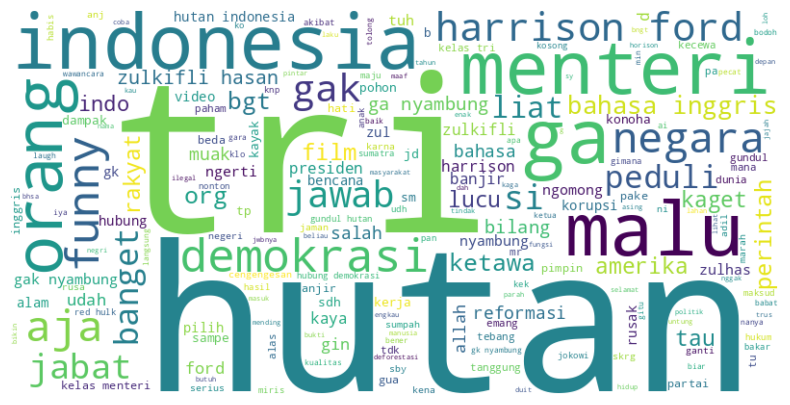

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Memuat data dari file CSV
df = pd.read_csv('data_gabungan_cleaned.csv')  # Ganti 'path_to_your_file.csv' dengan jalur file data Anda

# Gabungkan semua teks dalam kolom 'cleaned_komen' menjadi satu string besar
text = " ".join(judul for judul in df['stemmed_komen'].dropna())  # Pastikan tidak ada nilai NaN



# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Remove axis
plt.show()

**VISUALISASI KATA KUNCI TERBANYAK (WORDCLOUD)**

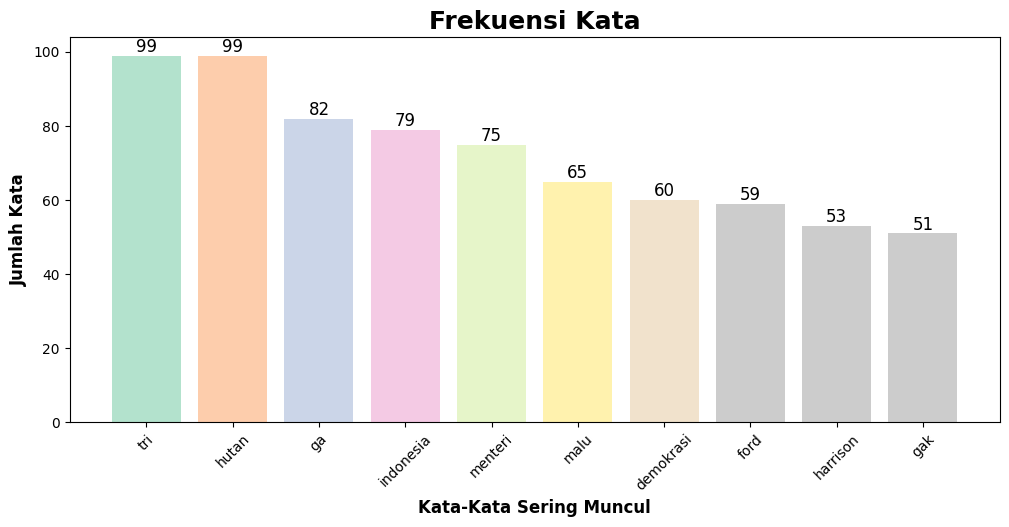

In [40]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = " ".join(judul for judul in df['stemmed_komen'].dropna())


tokens = [word for word in text.split() if word not in stop_words]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel2(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 1.6 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

**LABELING DATA (POSITIF, NEGATIF, NETRAL) LEXICON BASED**

In [41]:
# Unduh kamus leksikon positif dan negatif dari GITHUB
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep='\t', header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep='\t', header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"

In [42]:
# Tentukan sentimen dan skor untuk setiap ulasan
df[['Score', 'label']] = df['stemmed_komen'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
df.head(10)

,user,komen,Tanggal komentar,likes,cleaned_komen,stemmed_komen,tokens,Score,label
0,Rizka ⋆ ˚｡⋆୨୧˚,"""Years of Living Dangerously” adalah film doku...",12-2,600,years of living dangerously film dokumenter be...,years of living dangerously film dokumenter ba...,"['years', 'of', 'living', 'dangerously', 'film...",-1,Negatif
1,IMW,ZULKIFLI HASAN MAFIA DARI KERUSAKAN ALAM,12-3,468,zulkifli hasan mafia kerusakan alam,zulkifli hasan mafia rusa alam,"['zulkifli', 'hasan', 'mafia', 'rusa', 'alam']",-1,Negatif
2,mayang,itu kalo di film sudah di tonjok sama harrison...,12-2,805,kalo film tonjok harrison ford,kalo film tonjok harrison ford,"['kalo', 'film', 'tonjok', 'harrison', 'ford']",-1,Negatif
3,Fitriliciouz🎙️,"dia mentri, ditanya bhs Inggris jawabnya bhsa ...",12-1,11,mentri bhs inggris bhsa indonesia sekelas ment...,tri bhs inggris bhsa indonesia kelas menteri h...,"['tri', 'bhs', 'inggris', 'bhsa', 'indonesia',...",-1,Negatif
4,Z18.bebelyn,Buat apa harrison ford minta maaf ? Dia ga sal...,12-2,316,harrison ford maaf ga salah cukk yg salah tuh ...,harrison ford maaf ga salah cukk yg salah tuh ...,"['harrison', 'ford', 'maaf', 'ga', 'salah', 'c...",-2,Negatif
5,alif05,pelaku utama banjir sumatera Zulkifli Hasan 👍,12-1,446,pelaku utama banjir sumatera zulkifli hasan,laku utama banjir sumatera zulkifli hasan,"['laku', 'utama', 'banjir', 'sumatera', 'zulki...",0,Netral
6,yayay,Apa hubungan nya gundul nya tu hutan dgn jawab...,11-30,2879,hubungan nya gundul nya tu hutan dgn tu mentri...,hubung nya gundul nya tu hutan dgn tu tri demo...,"['hubung', 'nya', 'gundul', 'nya', 'tu', 'huta...",1,Positif
7,Feryanita,1. Ditanya malah ketawa2\n2. Jawabnya pake Bah...,12-2,2434,ketawa pake bahasa indonesia sekelas menteri,ketawa pake bahasa indonesia kelas menteri,"['ketawa', 'pake', 'bahasa', 'indonesia', 'kel...",-1,Negatif
8,Abdullah bin Mas'ud,"harrison ford bilng its not funny,,",12-1,366,harrison ford bilng its not funny,harrison ford bilng its not funny,"['harrison', 'ford', 'bilng', 'its', 'not', 'f...",0,Netral
9,Hadisaputra89,"org luar aja peduli sama hutan kita , sedangka...",11-30,10,org aja peduli hutan dsinii d rusak,org aja peduli hutan dsinii d rusak,"['org', 'aja', 'peduli', 'hutan', 'dsinii', 'd...",2,Positif


**VISUALISASI JUMLAH SENTIMEN PUBLIK **

/tmp/ipython-input-664524484.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")


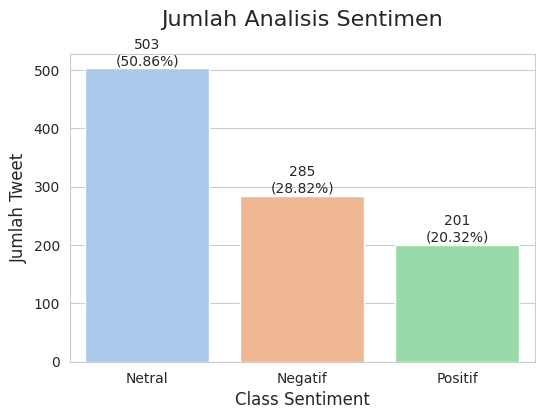

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = df['label'].value_counts()
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette="pastel")
plt.title("Jumlah Analisis Sentimen", fontsize=16, pad=20)
plt.xlabel("Class Sentiment", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)

total = len(df['label'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

# Menyimpan data yang sudah diproses ke file baru
df.to_csv('labeling_data.csv', index=False)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user              989 non-null    object
 1   komen             989 non-null    object
 2   Tanggal komentar  989 non-null    object
 3   likes             989 non-null    int64 
 4   cleaned_komen     989 non-null    object
 5   stemmed_komen     989 non-null    object
 6   tokens            989 non-null    object
 7   Score             989 non-null    int64 
 8   label             989 non-null    object
dtypes: int64(2), object(7)
memory usage: 69.7+ KB


In [45]:
label_count = df['label'].value_counts()
label_count

,count
label,
Netral,503
Negatif,285
Positif,201


**WORLDCLOUD LABEL POSITIF**

In [46]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Daftar stopwords tambahan yang ingin dikecualikan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
    'kak', 'tan', 'ajar', 'dan', 'di', 'ke', 'sih',
    'dari', 'adalah', 'yang', 'untuk', 'dengan', 'pada', 'ini'
])

# Fungsi untuk membuat word cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        colormap='tab20'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = df[df['label'] == 'Netral']['stemmed_komen'].str.cat(sep=' ')
sentimen_Negative = df[df['label'] == 'Negatif']['stemmed_komen'].str.cat(sep=' ')
sentimen_Positive = df[df['label'] == 'Positif']['stemmed_komen'].str.cat(sep=' ')

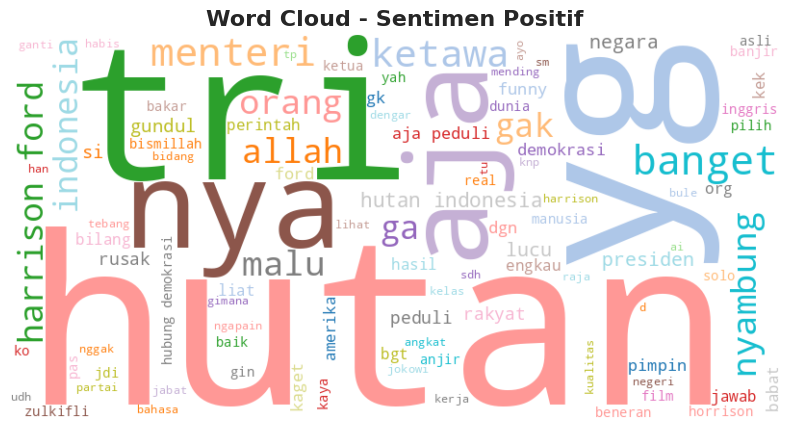

In [47]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Positive, "Word Cloud - Sentimen Positif")

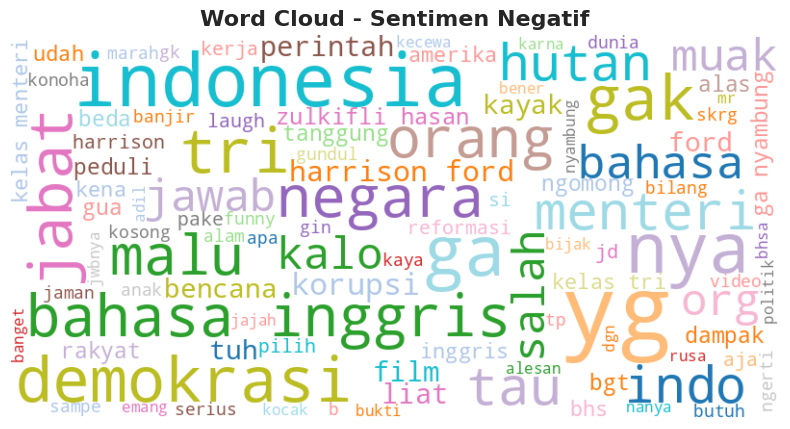

In [48]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Negative, "Word Cloud - Sentimen Negatif")

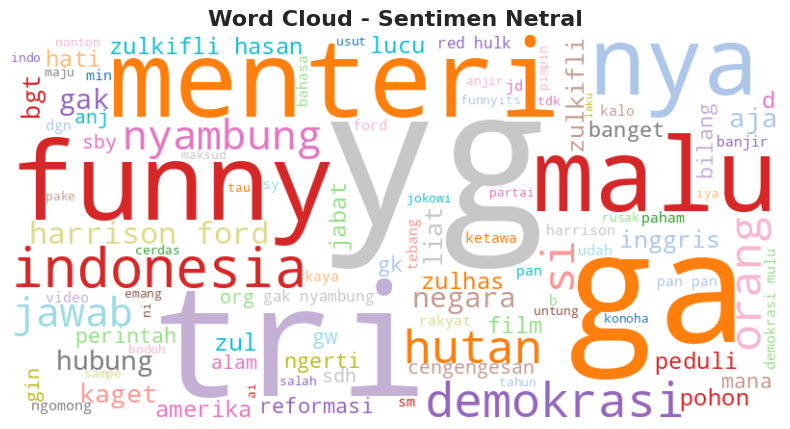

In [49]:
# Buat word cloud untuk masing-masing sentimen
generate_wordcloud(sentimen_Neutral, "Word Cloud - Sentimen Netral")

**FEATURE EXTRACTION**

In [50]:
df_list = df['stemmed_komen'].tolist()
print(df_list)

['years of living dangerously film dokumenter bas data lapang fiksi film angkat isu ubah iklim investigasi langsung lokasi dampak deforestasi indonesia film produksi dekat jurnalistik lapor ilmuwan aktivis tokoh masyarakat harrison ford salah narator jurnalis investigatif film unjung lokasilokasi dampak wawancara zulkifli hasan tampil film dasar fakta data ilmiah bukti kumpul langsung lapang skenario fiktif', 'zulkifli hasan mafia rusa alam', 'kalo film tonjok harrison ford', 'tri bhs inggris bhsa indonesia kelas menteri haaaaa', 'harrison ford maaf ga salah cukk yg salah tuh menteri ny', 'laku utama banjir sumatera zulkifli hasan', 'hubung nya gundul nya tu hutan dgn tu tri demokrasi yg', 'ketawa pake bahasa indonesia kelas menteri', 'harrison ford bilng its not funny', 'org aja peduli hutan dsinii d rusak', 'jawab tdk nyambung dgn prtanyaan', 'mr ford jebak bilang syuting nama film dokumenter ambil dri kisah nyataternyata sgt marah', 'uda bener konoha ambil alih belanda', 'i support 

In [51]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Isi nilai NaN dengan string kosong
df['stemmed_komen'] = df['stemmed_komen'].fillna('')

# Buat list dari kolom 'steming_data'
df_list = df['stemmed_komen'].tolist()

# Buat objek TfidfVectorizer
df_tfidf = TfidfVectorizer()

# Lakukan transformasi fitur
X = df_tfidf.fit_transform(df_list)

print('Feature Extraction Selesai!!!')
print('===== Bentuk Transformasi Feature Extraction =====')
print(X.shape)

# Dapatkan nama fitur (kata-kata unik)
feature_names = df_tfidf.get_feature_names_out()

# Hitung total skor TF-IDF untuk setiap term (kata)
tfidf_sums = X.sum(axis=0)

# Buat DataFrame untuk menampilkan hasil
tfidf_df = pd.DataFrame({
    'term': feature_names,
    'tfidf_sum': tfidf_sums.tolist()[0]
})

# Urutkan berdasarkan skor TF-IDF terbesar
tfidf_df = tfidf_df.sort_values('tfidf_sum', ascending=False)

print("\n==== Top 20 Terms by Total TF-IDF Score ====")
print(tfidf_df.head(20))

print("\n==== IDF Values ====")
idf_values = df_tfidf.idf_
idf_df = pd.DataFrame({
    'Term': feature_names,
    'IDF': idf_values
})
print(idf_df.head(20))

print("\n==== TF-IDF values for the first 5 documents ====")
for i in range(min(5, len(df_list))):
    first_document_tfidf = pd.DataFrame(
        X[i].T.todense(),
        index=feature_names,
        columns=["TF-IDF"]
    )
    print(f"\nDocument {i+1} TF-IDF Values:")
    print(first_document_tfidf.sort_values("TF-IDF", ascending=False).head(10))

Feature Extraction Selesai!!!
===== Bentuk Transformasi Feature Extraction =====
(989, 2023)

==== Top 20 Terms by Total TF-IDF Score ====
           term  tfidf_sum
1992         yg  31.056272
1864        tri  28.873800
1157    menteri  24.587025
1113       malu  23.995224
1327        not  21.728184
713       hutan  21.153480
557          ga  20.605138
1339        nya  20.034120
552       funny  19.804138
775         its  19.458400
401   demokrasi  18.691636
1342   nyambung  17.914472
744   indonesia  17.546874
1973         ya  16.184898
539        ford  15.762802
563         gak  15.555596
665    harrison  14.563578
141      bahasa  14.395865
1382      orang  13.856796
2013   zulkifli  12.662318

==== IDF Values ====
         Term       IDF
0      aamiin  7.204558
1        abis  7.204558
2       about  7.204558
3          ac  7.204558
4    acakadul  7.204558
5       acara  7.204558
6        aceh  6.799093
7   acehsumut  7.204558
8       actor  6.799093
9       adalh  7.204558
10      

In [52]:
y = df['label']
print(y)

0      Negatif
1      Negatif
2      Negatif
3      Negatif
4      Negatif
        ...   
984     Netral
985    Negatif
986    Negatif
987    Negatif
988    Negatif
Name: label, Length: 989, dtype: object


In [53]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5578 stored elements and shape (989, 2023)>
  Coords	Values
  (0, 1988)	0.12839573488574244
  (0, 1359)	0.10881686040007833
  (0, 1061)	0.12839573488574244
  (0, 384)	0.12839573488574244
  (0, 532)	0.4461899295720712
  (0, 454)	0.11604284043129588
  (0, 175)	0.12839573488574244
  (0, 387)	0.25679146977148487
  (0, 1025)	0.25679146977148487
  (0, 530)	0.12839573488574244
  (0, 78)	0.11206609665323125
  (0, 773)	0.12116975485452487
  (0, 1897)	0.11206609665323125
  (0, 728)	0.12839573488574244
  (0, 767)	0.12839573488574244
  (0, 1023)	0.21763372080015667
  (0, 1068)	0.12116975485452487
  (0, 383)	0.1994264043975694
  (0, 394)	0.10881686040007833
  (0, 744)	0.06503424315043611
  (0, 1498)	0.12839573488574244
  (0, 397)	0.12839573488574244
  (0, 844)	0.12839573488574244
  (0, 1026)	0.11604284043129588
  (0, 736)	0.12839573488574244
  :	:
  (986, 1386)	0.45265623731601506
  (986, 1432)	0.1422135731408584
  (986, 1245)	0.13631044

**KLASIFIKASI MODEL MACHINE LEARNING**

In [54]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

Jumlah data training (X_train): 791
Jumlah data testing (X_test): 198


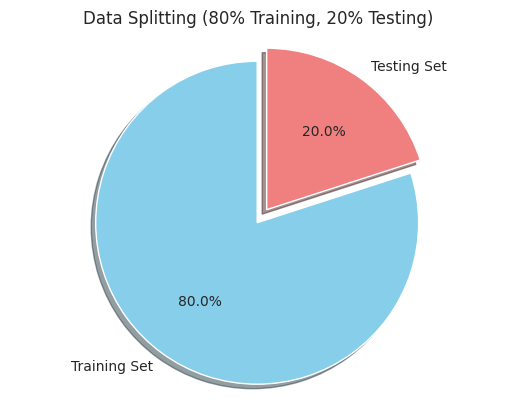

In [55]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting datasets
print("Jumlah data training (X_train):", X_train.shape[0])
print("Jumlah data testing (X_test):", X_test.shape[0])

# Visualize the data split
import matplotlib.pyplot as plt

train_size = X_train.shape[0]
test_size = X_test.shape[0]
total_size = train_size + test_size

labels = ['Training Set', 'Testing Set']
sizes = [train_size, test_size]
colors = ['skyblue', 'lightcoral']
explode = (0.1, 0)  # explode 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Data Splitting (80% Training, 20% Testing)')
plt.show()


Training and evaluating: Logistic Regression
Accuracy: 0.6364
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.88      0.35      0.50        60
      Netral       0.60      0.95      0.73       102
     Positif       0.73      0.22      0.34        36

    accuracy                           0.64       198
   macro avg       0.73      0.51      0.52       198
weighted avg       0.70      0.64      0.59       198



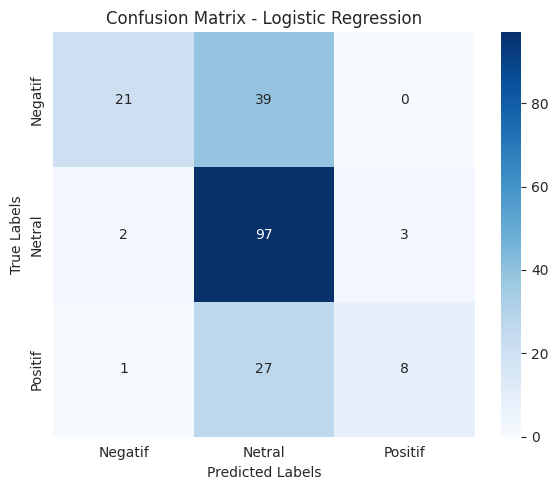


Training and evaluating: Decision Tree
Accuracy: 0.6263
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.67      0.43      0.53        60
      Netral       0.63      0.78      0.70       102
     Positif       0.55      0.50      0.52        36

    accuracy                           0.63       198
   macro avg       0.62      0.57      0.58       198
weighted avg       0.63      0.63      0.62       198



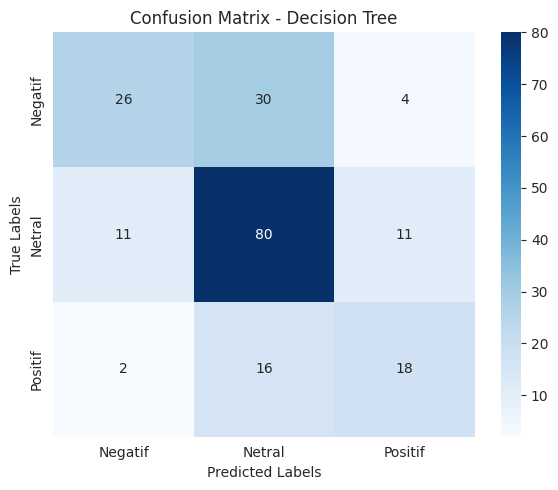


Training and evaluating: Random Forest
Accuracy: 0.6111
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.70      0.35      0.47        60
      Netral       0.59      0.87      0.70       102
     Positif       0.65      0.31      0.42        36

    accuracy                           0.61       198
   macro avg       0.65      0.51      0.53       198
weighted avg       0.63      0.61      0.58       198



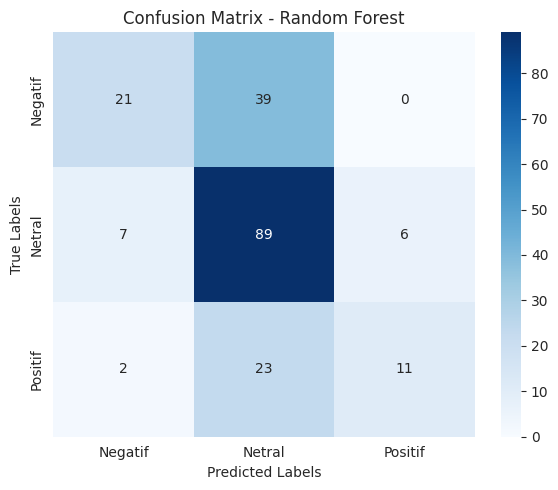


Training and evaluating: SVM
Accuracy: 0.6717
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.86      0.40      0.55        60
      Netral       0.63      0.92      0.75       102
     Positif       0.75      0.42      0.54        36

    accuracy                           0.67       198
   macro avg       0.74      0.58      0.61       198
weighted avg       0.72      0.67      0.65       198



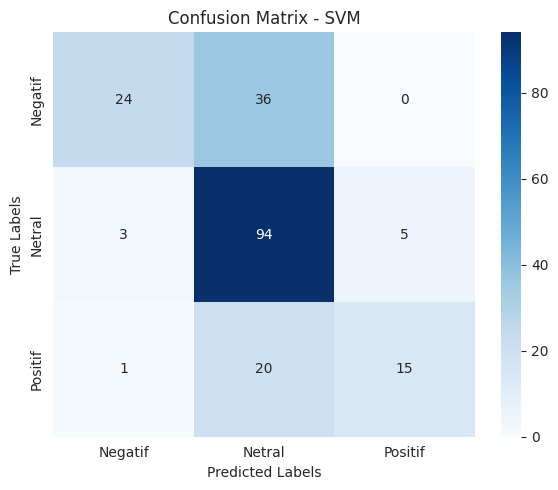


Training and evaluating: KNN
Accuracy: 0.5303
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.51      0.45      0.48        60
      Netral       0.55      0.69      0.61       102
     Positif       0.44      0.22      0.30        36

    accuracy                           0.53       198
   macro avg       0.50      0.45      0.46       198
weighted avg       0.52      0.53      0.51       198



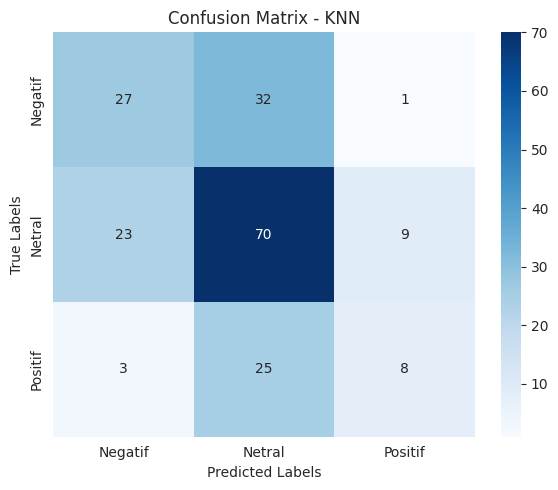


Training and evaluating: Naive Bayes
Accuracy: 0.5859
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.78      0.23      0.36        60
      Netral       0.56      0.98      0.71       102
     Positif       1.00      0.06      0.11        36

    accuracy                           0.59       198
   macro avg       0.78      0.42      0.39       198
weighted avg       0.71      0.59      0.50       198



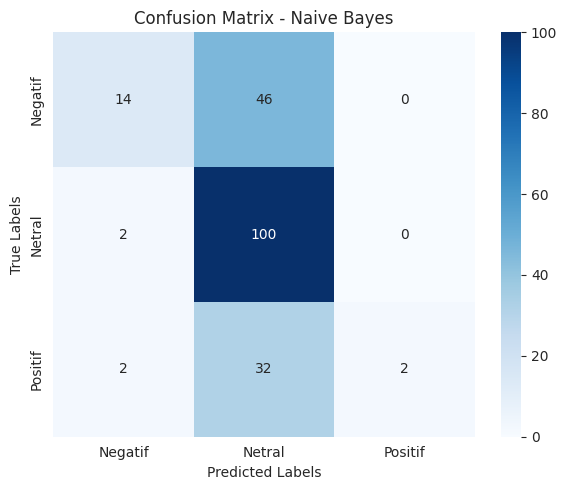


RINGKASAN AKHIR: PERBANDINGAN MODEL
Logistic Regression  | Accuracy: 0.6364
Decision Tree        | Accuracy: 0.6263
Random Forest        | Accuracy: 0.6111
SVM                  | Accuracy: 0.6717
KNN                  | Accuracy: 0.5303
Naive Bayes          | Accuracy: 0.5859


In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Baca data (ganti nama file sesuai kebutuhan)
df = pd.read_csv('labeling_data.csv')

# 2. Siapkan fitur (X) dan target (y)
# Misal: X = kolom teks (cleaned_komen), y = kolom sentimen (positif/negatif/netral)
X = df['cleaned_komen']  # → ini string, harus diubah jadi numerik!
y = df['label']      # → pastikan ini sudah ada dan berisi 'positif', 'negatif', 'netral'

# 3. Ubah teks jadi vektor numerik (contoh: TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_vec = vectorizer.fit_transform(X)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

# 5. Definisikan classifier yang ingin diuji
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': MultinomialNB()
}

# 6. Train & evaluate setiap classifier
results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training and evaluating: {name}")
    print(f"{'='*50}")

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Simpan hasil
    results[name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm
    }

    # Tampilkan hasil
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

# 7. Ringkasan akhir
print("\n" + "="*60)
print("RINGKASAN AKHIR: PERBANDINGAN MODEL")
print("="*60)
for name, res in results.items():
    print(f"{name:20} | Accuracy: {res['accuracy']:.4f}")

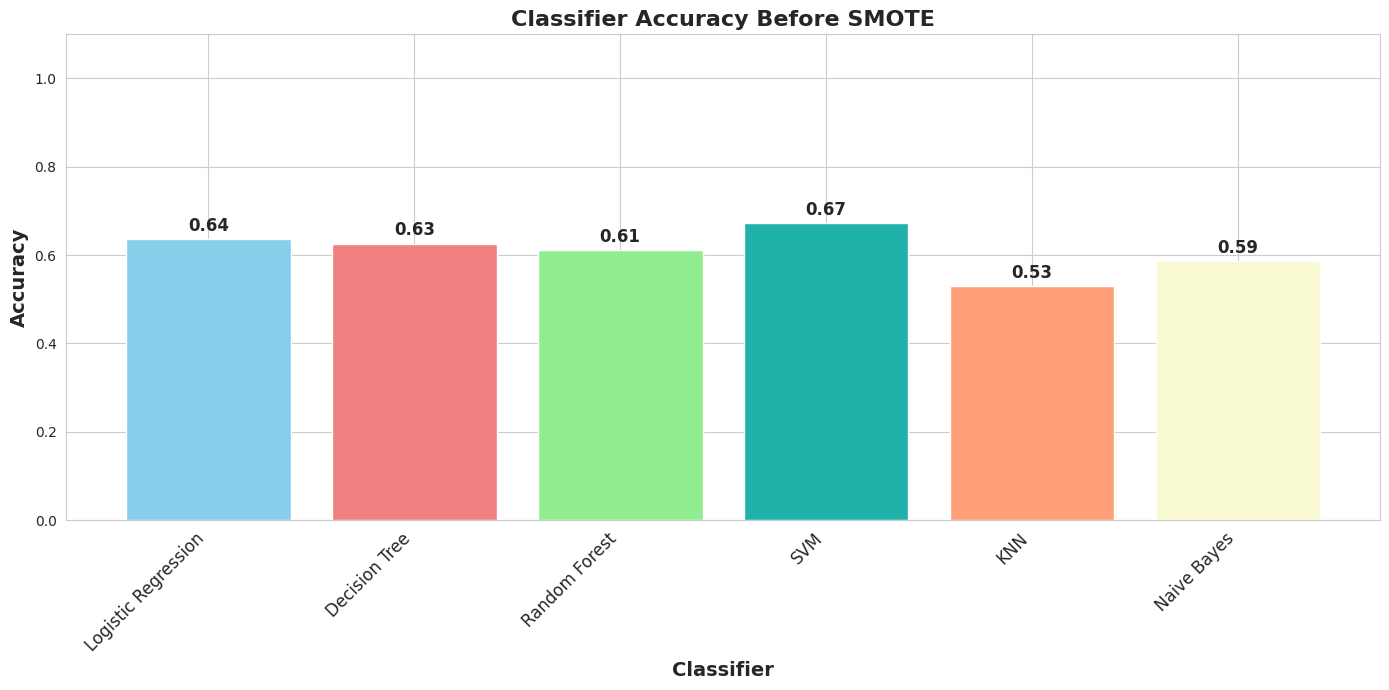

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'results' dictionary is defined from previous code
classifiers = list(results.keys())
accuracy_before = [results[name]['accuracy'] for name in classifiers]

# Improved Plotting
plt.figure(figsize=(14, 7))  # Slightly larger figure for better readability
bars = plt.bar(classifiers, accuracy_before, color=['skyblue', 'lightcoral', 'lightgreen', 'lightseagreen', 'lightsalmon', 'lightgoldenrodyellow'])
plt.xlabel("Classifier", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Classifier Accuracy Before SMOTE", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjust font size and rotation

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracy_before):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{acc:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  # Ensure labels are not cut off
plt.show()

In [58]:
def count_rows_csv(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return sum(1 for line in f) - 1  # -1 untuk header

n1 = count_rows_csv('tiktok 29 nov (feovles).csv')
n2 = count_rows_csv('tiktok 29 nov (sitisulastri).csv')
total = n1 + n2

print(f"File 1: {n1} baris")
print(f"File 2: {n2} baris")
print(f"Total: {total} baris")

File 1: 1164 baris
File 2: 365 baris
Total: 1529 baris
